# Medical Image Segmentation with U-Net

This notebook builds a small semantic-segmentation pipeline with **PyTorch U-Net**.

### Why Oxford-IIIT Pet?

The project brief asks for medical image segmentation, but large clinical datasets can be impractical on a CPU-only, low-storage computer. The Oxford-IIIT Pet dataset provides real pixel-level segmentation masks in a compact, open benchmark. The same U-Net workflow can later be adapted to a medical dataset such as organ or tumor segmentation.

**Goal:** learn the complete segmentation workflow without requiring a GPU.

> Educational use only. This notebook is not a medical diagnostic system.


## 1. Imports and Configuration

The settings below intentionally use a small image size and a small training subset. Increase them only if your computer has enough RAM, storage, and CPU time.


In [1]:
from pathlib import Path
import random
import zipfile
import requests

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")
IMAGE_SIZE = 128
BATCH_SIZE = 4
EPOCHS = 3
TRAIN_LIMIT = 400
VAL_LIMIT = 80

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
DATASET_DIR = DATA_DIR / "oxford-iiit-pet"
DATASET_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)
print("Project:", ROOT)


Device: cpu
Project: c:\Users\user\Desktop\Medical-Image-Segmentation


## 2. Download the Open Dataset

Only the dataset archive is downloaded. The raw archive is not committed to GitHub.

The Oxford-IIIT Pet images are available from the Visual Geometry Group at Oxford.


In [3]:
BASE_URL = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/"
files_to_download = {
    "images.tar.gz": BASE_URL + "images.tar.gz",
    "annotations.tar.gz": BASE_URL + "annotations.tar.gz",
}

for filename, url in files_to_download.items():
    target = DATA_DIR / filename
    if not target.exists():
        print("Downloading", filename)
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        target.write_bytes(response.content)
    else:
        print("Already downloaded:", filename)

print("Download complete.")

Download complete.


## 3. Extract Only When Needed

The extraction step is local and uses Python's standard library. If the folders already exist, nothing is extracted again.


In [4]:
import tarfile

images_root = DATA_DIR / "images"
annotations_root = DATA_DIR / "annotations"

if not images_root.exists():
    with tarfile.open(DATA_DIR / "images.tar.gz", "r:gz") as tar:
        tar.extractall(DATA_DIR)

if not annotations_root.exists():
    with tarfile.open(DATA_DIR / "annotations.tar.gz", "r:gz") as tar:
        tar.extractall(DATA_DIR)

print("Images:", images_root.exists())
print("Annotations:", annotations_root.exists())


Images: True
Annotations: True


## 4. Build Image/Mask Pairs

Oxford-IIIT Pet trimaps contain:
- `1`: foreground
- `2`: background
- `3`: uncertain boundary

For a simple binary segmentation problem, foreground pixels are represented as `1` and the other classes as `0`.


In [5]:
image_files = sorted(images_root.glob("*.jpg"))
pairs = []

for image_path in image_files:
    trimap_path = annotations_root / "trimaps" / (image_path.stem + ".png")
    if trimap_path.exists():
        pairs.append((image_path, trimap_path))

random.shuffle(pairs)

train_pairs = pairs[:TRAIN_LIMIT]
val_pairs = pairs[TRAIN_LIMIT:TRAIN_LIMIT + VAL_LIMIT]

print("Available pairs:", len(pairs))
print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))


Available pairs: 7390
Training pairs: 400
Validation pairs: 80


## 5. Inspect an Example


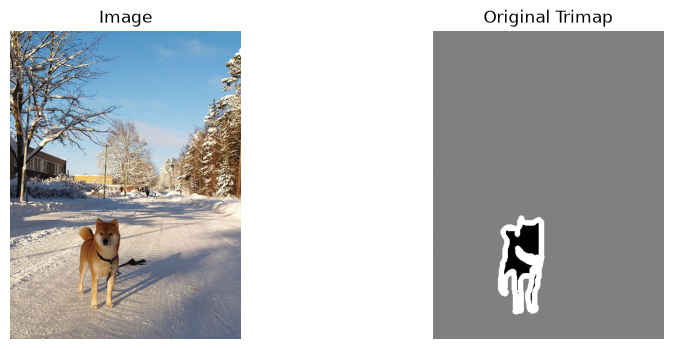

In [6]:
image_path, mask_path = train_pairs[0]
image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Original Trimap")
plt.axis("off")
plt.show()


## 6. Dataset Class

Images and masks receive the same spatial resize. The mask uses nearest-neighbor interpolation so class labels remain discrete.


In [7]:
class PetSegmentationDataset(Dataset):
    def __init__(self, pairs, image_size=128):
        self.pairs = pairs
        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])
        self.mask_transform = transforms.Resize(
            (image_size, image_size),
            interpolation=transforms.InterpolationMode.NEAREST,
        )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        image = self.image_transform(image)
        mask = self.mask_transform(mask)
        mask = torch.from_numpy(np.array(mask)).float()
        mask = (mask == 1).float().unsqueeze(0)

        return image, mask

train_dataset = PetSegmentationDataset(train_pairs, IMAGE_SIZE)
val_dataset = PetSegmentationDataset(val_pairs, IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


Train batches: 100
Validation batches: 20


## 7. U-Net Model

This compact U-Net keeps the number of channels small so it is practical for CPU training. It still demonstrates the core encoder-decoder and skip-connection idea used by U-Net.


In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(3, 32)
        self.down2 = DoubleConv(32, 64)
        self.down3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))

        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv1(x)

        return self.out(x)


model = UNet().to(DEVICE)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable parameters: 466529


## 8. Loss and Metrics

Binary cross-entropy handles pixel classification, while Dice and IoU summarize overlap between the predicted and true foreground regions.


In [9]:
def dice_score(logits, targets, smooth=1e-6):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > 0.5).float()

    intersection = (predictions * targets).sum(dim=(1, 2, 3))
    total = predictions.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    return ((2 * intersection + smooth) / (total + smooth)).mean()


def iou_score(logits, targets, smooth=1e-6):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > 0.5).float()

    intersection = (predictions * targets).sum(dim=(1, 2, 3))
    union = predictions.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection

    return ((intersection + smooth) / (union + smooth)).mean()


criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## 9. CPU-Friendly Training

Three epochs on a small subset are enough to demonstrate the complete workflow. This is intentionally a learning/demo configuration rather than a state-of-the-art training recipe.


In [10]:
history = {"train_loss": [], "val_dice": [], "val_iou": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    dice_values = []
    iou_values = []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            dice_values.append(dice_score(logits, masks).item())
            iou_values.append(iou_score(logits, masks).item())

    train_loss = running_loss / max(len(train_loader), 1)
    val_dice = float(np.mean(dice_values)) if dice_values else 0.0
    val_iou = float(np.mean(iou_values)) if iou_values else 0.0

    history["train_loss"].append(train_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"loss={train_loss:.4f} | dice={val_dice:.4f} | iou={val_iou:.4f}"
    )


Epoch 1/3 | loss=0.6237 | dice=0.0250 | iou=0.0250
Epoch 2/3 | loss=0.5779 | dice=0.0250 | iou=0.0250
Epoch 3/3 | loss=0.5446 | dice=0.0250 | iou=0.0250


## 10. Plot Training Results


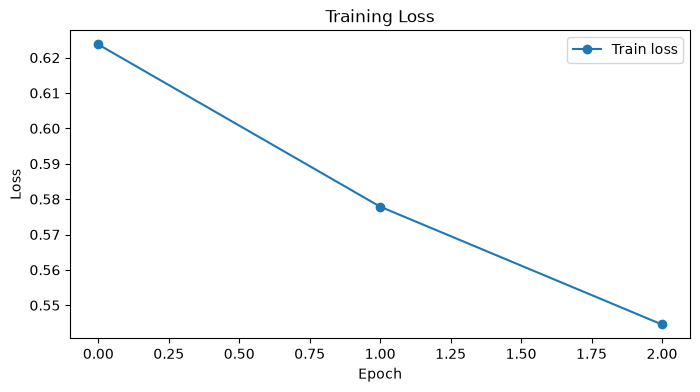

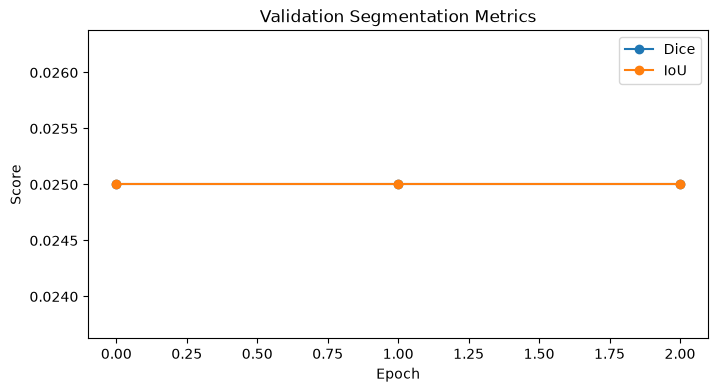

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], marker="o", label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["val_dice"], marker="o", label="Dice")
plt.plot(history["val_iou"], marker="o", label="IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Segmentation Metrics")
plt.legend()
plt.show()


## 11. Visualize Predictions


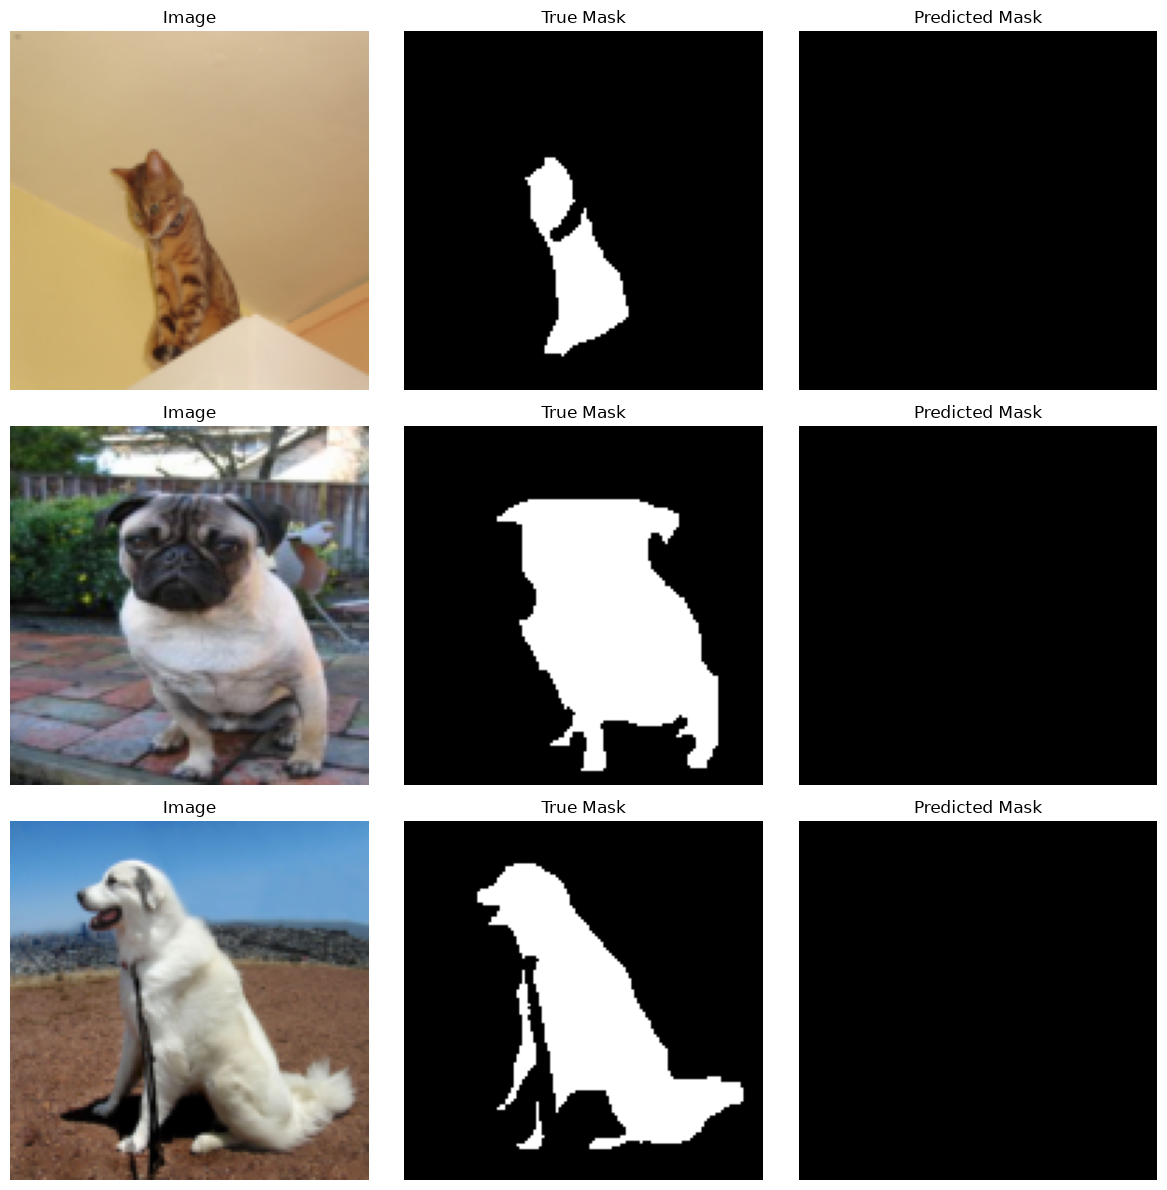

In [12]:
model.eval()

images, masks = next(iter(val_loader))
with torch.no_grad():
    logits = model(images.to(DEVICE))
    predictions = (torch.sigmoid(logits).cpu() > 0.5).float()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

count = min(3, len(images))
plt.figure(figsize=(12, 4 * count))

for i in range(count):
    display_image = (images[i] * std + mean).clamp(0, 1)

    plt.subplot(count, 3, i * 3 + 1)
    plt.imshow(display_image.permute(1, 2, 0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(count, 3, i * 3 + 2)
    plt.imshow(masks[i, 0], cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(count, 3, i * 3 + 3)
    plt.imshow(predictions[i, 0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 12. Save the Lightweight Model

The Flask app expects the checkpoint at `models/unet_pet_segmentation.pth`.


In [13]:
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "unet_pet_segmentation.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Saved:", MODEL_PATH)
print("Size (MB):", round(MODEL_PATH.stat().st_size / (1024 ** 2), 2))


Saved: c:\Users\user\Desktop\Medical-Image-Segmentation\models\unet_pet_segmentation.pth
Size (MB): 1.79


## 13. Single-Image Inference

This is the same basic operation used by the Flask application: resize an image, run U-Net, threshold the output, and display the mask.


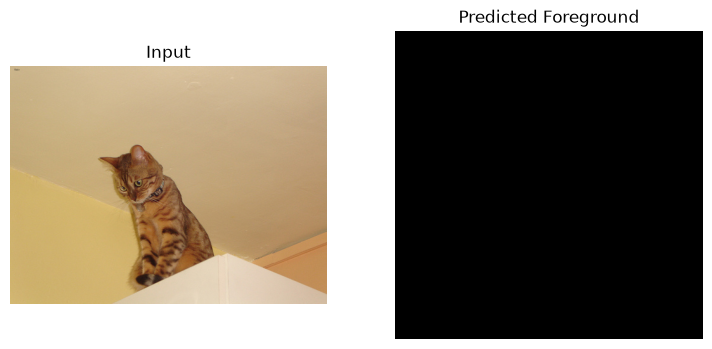

In [14]:
def predict_mask(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])(image).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        probability = torch.sigmoid(model(tensor))[0, 0]

    mask = (probability > 0.5).numpy().astype(np.uint8)
    return image, mask


sample_image, sample_prediction = predict_mask(val_pairs[0][0])

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_prediction, cmap="gray")
plt.title("Predicted Foreground")
plt.axis("off")
plt.show()


## 14. Interview Takeaways

- **Problem:** pixel-level semantic segmentation.
- **Architecture:** compact U-Net with encoder, decoder, and skip connections.
- **Framework:** PyTorch.
- **Dataset:** Oxford-IIIT Pet segmentation benchmark.
- **Metrics:** Dice coefficient and Intersection over Union (IoU).
- **Deployment:** Flask web app for image upload and mask prediction.
- **Resource strategy:** small image size, small subset, CPU-only execution, and on-demand dataset download.

### How to extend this toward actual medical imaging

Once the pipeline is understood, replace the dataset class with a suitable open medical segmentation dataset. Keep the same U-Net, loss, metrics, visualization, and deployment concepts while adapting image format and mask labels.
